In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

##definig the features and target variables here

In [2]:
df = pd.read_csv('../bank-additional-full.csv', sep=';')

X = df.drop('y', axis=1)
#target mapping
y = df['y'].map({'yes': 1, 'no': 0})

#finding categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Numeric columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


##doing one hot encoding here for categorical variables

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

In [4]:
lgbm = LGBMClassifier(random_state=1, verbose = -1) #verbose = -1 so that output during grid search isnt too much

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', lgbm)
])


In [5]:
param_grid = { #hyper parameter grid for grid search, smaller grid because of computational resources
    'model__n_estimators': [100, 200],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
    'model__min_child_samples': [20, 50]
}

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [7]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

#print("\nBest parameters found:", grid_search.best_params_)

#best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                                        ('num',
                                                                         'passthrough',
                                                                         Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                                       ('model',
                                        LGBMClassifier(random_state=1,
                                                       verbose=-1))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [-1, 10, 20],
                         'model__min_child_samples': [20, 50],
                         'model__n_estimators': [100, 200],
                         'model__num_leaves': [31, 50]},
             scoring='accuracy', verbose=1)

In [8]:
print("Best parameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best parameters found: {'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 20, 'model__n_estimators': 100, 'model__num_leaves': 31}

Accuracy: 0.9186695799951444

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      7310
           1       0.66      0.57      0.61       928

    accuracy                           0.92      8238
   macro avg       0.80      0.76      0.78      8238
weighted avg       0.91      0.92      0.92      8238


Confusion Matrix:
 [[7043  267]
 [ 403  525]]


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



AUC: 0.9502057880088683


/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


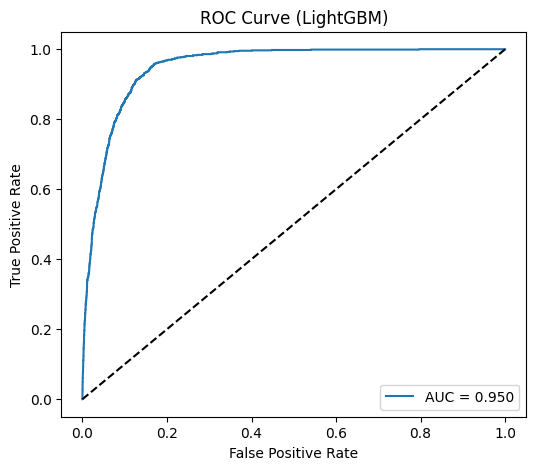

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print("\nAUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (LightGBM)')
plt.legend()
plt.show()

##Using Shap to find and plot the feature importance

In [10]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#taking sample just like with RF, because
sample_size = 2000  
X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

#transforming categorical features
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_sample)

#convert sparse matrix to dense if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

#get the transformed feature names
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

#computing shap values for light gbm
print("Calculating SHAP values with LightGBM...")

#light gbm requires the underlying model
lgb_model = best_model.named_steps['model']

# Use TreeExplainer for tree based models 
explainer = shap.TreeExplainer(lgb_model, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_transformed)

# If shap_values is a list binary classification, use the 2nd element
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

print(f"✅ SHAP values calculated. Shape: {shap_values_class1.shape}")


#computing mean shap values
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)


#displaying top features
top_n = 20
top_features = feature_importance.head(top_n)

print(f"\nTop {top_n} most important features (LightGBM):")
print("="*70)
for i, row in enumerate(top_features.itertuples(), 1):
    print(f"{i:>2}. {row.feature:<45} {row.importance:.6f}")



/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


Calculating SHAP values with LightGBM...
✅ SHAP values calculated. Shape: (2000, 63)

Top 20 most important features (LightGBM):
 1. num__duration                                 1.384402
 2. num__emp.var.rate                             0.688270
 3. num__nr.employed                              0.299538
 4. num__euribor3m                                0.253449
 5. num__cons.conf.idx                            0.140049
 6. cat__contact_cellular                         0.139051
 7. cat__month_may                                0.069541
 8. num__pdays                                    0.049046
 9. num__age                                      0.045578
10. num__cons.price.idx                           0.042654
11. cat__default_no                               0.040084
12. cat__poutcome_failure                         0.024439
13. num__campaign                                 0.021371
14. cat__month_apr                                0.020786
15. cat__month_oct                           

/Users/iankwak/Documents/Bank_Marketing_ML/src/venv/lib/python3.9/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


##plotting the feature importance


✅ Saved: LGBM_feature_importance_top20.png


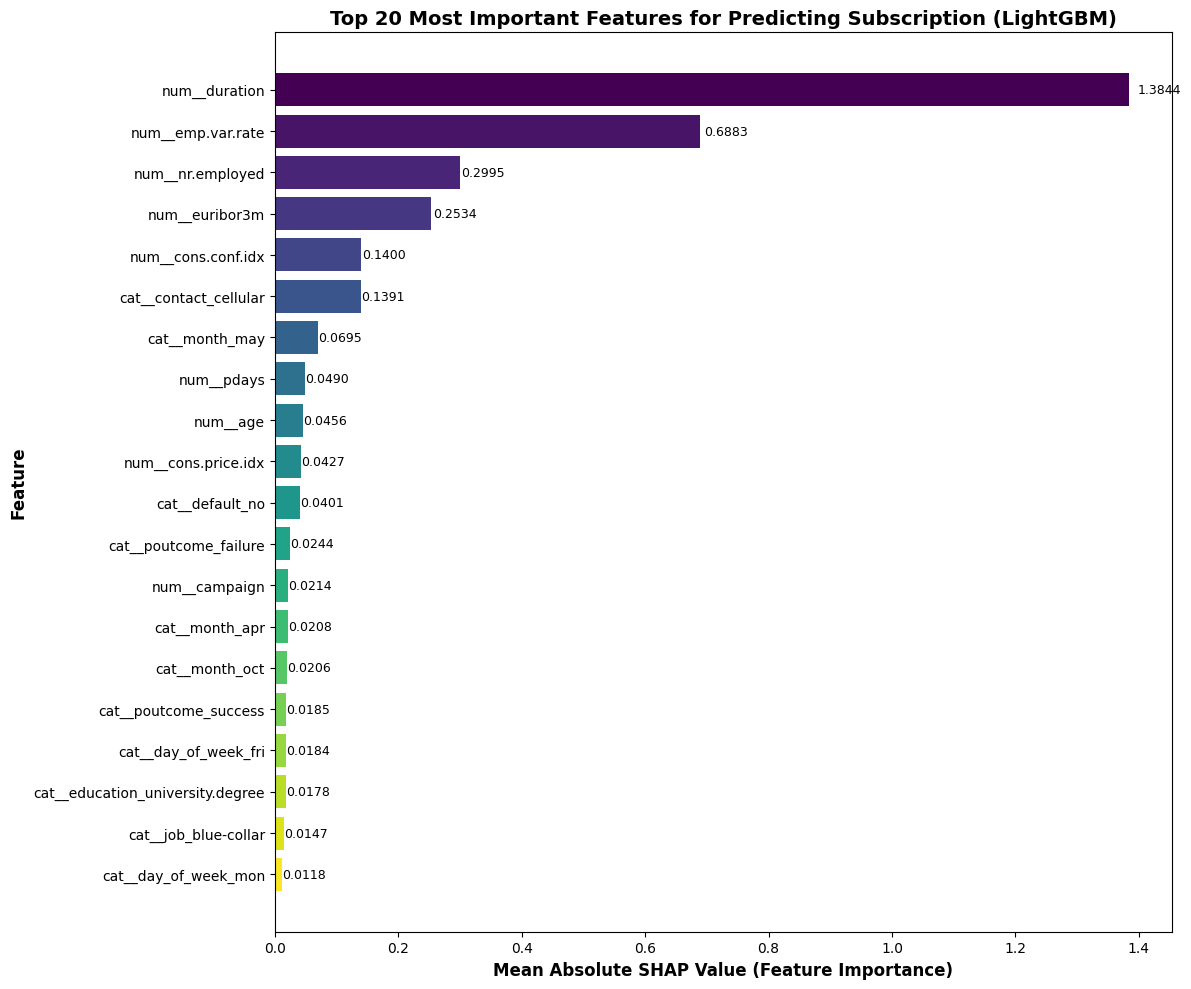

✅ Saved: LGBM_all_feature_importance.csv (all 63 features)

SUMMARY
Total features analyzed: 63
Most important feature: num__duration
Importance range: 0.000000 to 1.384402

In top 20:
  Categorical features: 11
  Numerical features: 9


In [11]:
# Plot
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'], fontsize=10)
plt.xlabel('Mean Absolute SHAP Value (Feature Importance)', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features for Predicting Subscription (LightGBM)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top_features['importance'])):
    plt.text(val + val*0.01, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'output/LGBM_feature_importance_top{top_n}.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Saved: LGBM_feature_importance_top{top_n}.png")
plt.show()

#save results and summary
feature_importance.to_csv('output/LGBM_all_feature_importance.csv', index=False)
print(f"✅ Saved: LGBM_all_feature_importance.csv (all {len(feature_importance)} features)")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Total features analyzed: {len(feature_names)}")
print(f"Most important feature: {top_features.iloc[0]['feature']}")
print(f"Importance range: {feature_importance['importance'].min():.6f} to {feature_importance['importance'].max():.6f}")

categorical_count = sum(1 for f in top_features['feature'] if 'cat__' in f)
numerical_count = sum(1 for f in top_features['feature'] if 'num__' in f)
print(f"\nIn top {top_n}:")
print(f"  Categorical features: {categorical_count}")
print(f"  Numerical features: {numerical_count}")
